# ECMWF atm forcing — `swrad` and `Tair` time series at domain center

File: `/dataSIO/PFM_Simulations/Archive/Forcing/atm_ecmwf_LV4_2026051500.nc`

`Tair` is the only temperature in this forcing file (air temperature at the surface, °C).
Note `swrad` (shortwave) and `Tair` use different time dimensions (`srf_time` 102 pts vs `tair_time` 101 pts).

In [1]:
import numpy as np
import netCDF4 as nc
import datetime as DT
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

fn = '/dataSIO/PFM_Simulations/Archive/Forcing/atm_ecmwf_LV4_2026051500.nc'
d  = nc.Dataset(fn)
ny, nx = d.dimensions['er'].size, d.dimensions['xr'].size
j0, i0 = ny//2, nx//2          # center of the domain
print(f'grid: {ny} x {nx}   center index (j={j0}, i={i0})')
print(f'lon = {float(d.variables["lon"][j0,i0]):.4f}, lat = {float(d.variables["lat"][j0,i0]):.4f}')

grid: 1141 x 486   center index (j=570, i=243)
lon = -117.1385, lat = 32.5524


In [2]:
# Times in this file are stored as 'days' (since 1999-01-01 by PFM convention).
ref = DT.datetime(1999, 1, 1)
def days_to_dt(arr):
    return np.array([ref + DT.timedelta(days=float(v)) for v in arr])

t_swrad = days_to_dt(d.variables['srf_time'][:])
t_tair  = days_to_dt(d.variables['tair_time'][:])

swrad_c = np.array(d.variables['swrad'][:, j0, i0])
tair_c  = np.array(d.variables['Tair' ][:, j0, i0])

print(f'swrad: {len(swrad_c)} samples; range [{swrad_c.min():.2f}, {swrad_c.max():.2f}] W/m^2')
print(f'  time: {t_swrad[0]}  ..  {t_swrad[-1]}')
print(f'Tair : {len(tair_c)} samples; range [{tair_c.min():.2f}, {tair_c.max():.2f}] degC')
print(f'  time: {t_tair[0]}  ..  {t_tair[-1]}')

KeyboardInterrupt: 

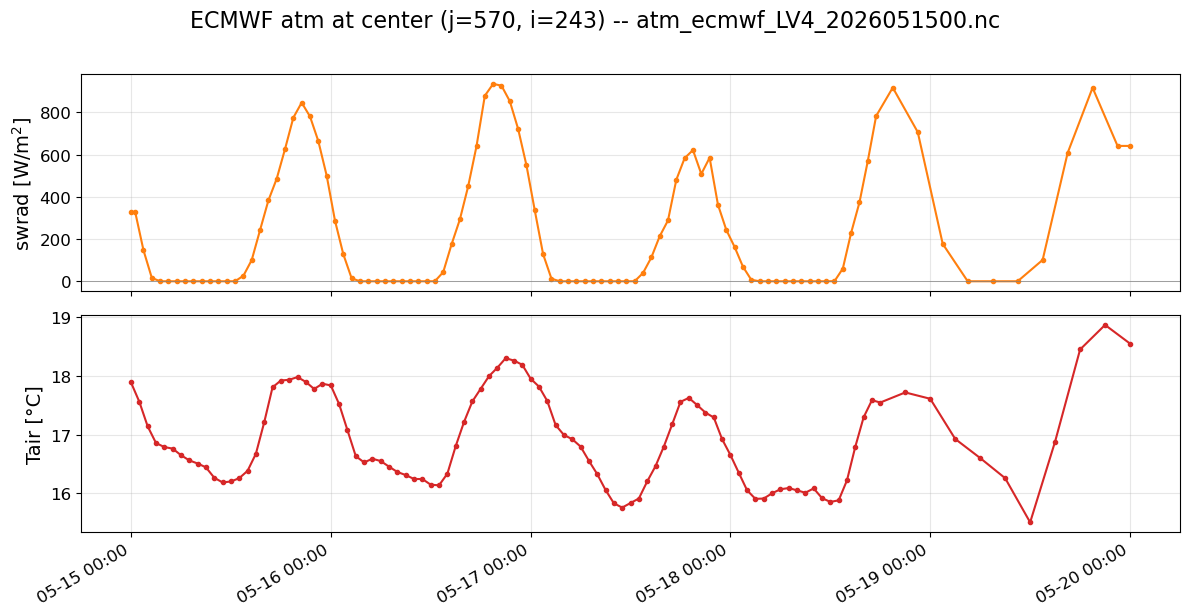

In [3]:
LBL_FS, TICK_FS, TITLE_FS = 14, 12, 16

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(t_swrad, swrad_c, '-o', ms=3, color='tab:orange', label='swrad')
ax.set_ylabel('swrad [W/m$^2$]', fontsize=LBL_FS)
ax.tick_params(axis='both', labelsize=TICK_FS)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', lw=0.5)

ax = axes[1]
ax.plot(t_tair, tair_c, '-o', ms=3, color='tab:red', label='Tair')
ax.set_ylabel('Tair [°C]', fontsize=LBL_FS)
ax.tick_params(axis='both', labelsize=TICK_FS)
ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))
fig.autofmt_xdate()
fig.suptitle(f'ECMWF atm at center (j={j0}, i={i0}) -- {fn.split("/")[-1]}', y=1.02, fontsize=TITLE_FS)
fig.tight_layout()
plt.show()

center (j=570, i=243)  lon = -117.1385, lat = 32.5524  h = 12.28 m
time range: 2026-05-15 00:00:00  ..  2026-05-20 00:00:00  (121 steps)
zeta range: [-1.128, 1.137] m


/tmp/ipykernel_801563/131834982.py:56: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pc = ax.pcolormesh(T_dt2, z_rho, arr, cmap=cmap, shading='auto')


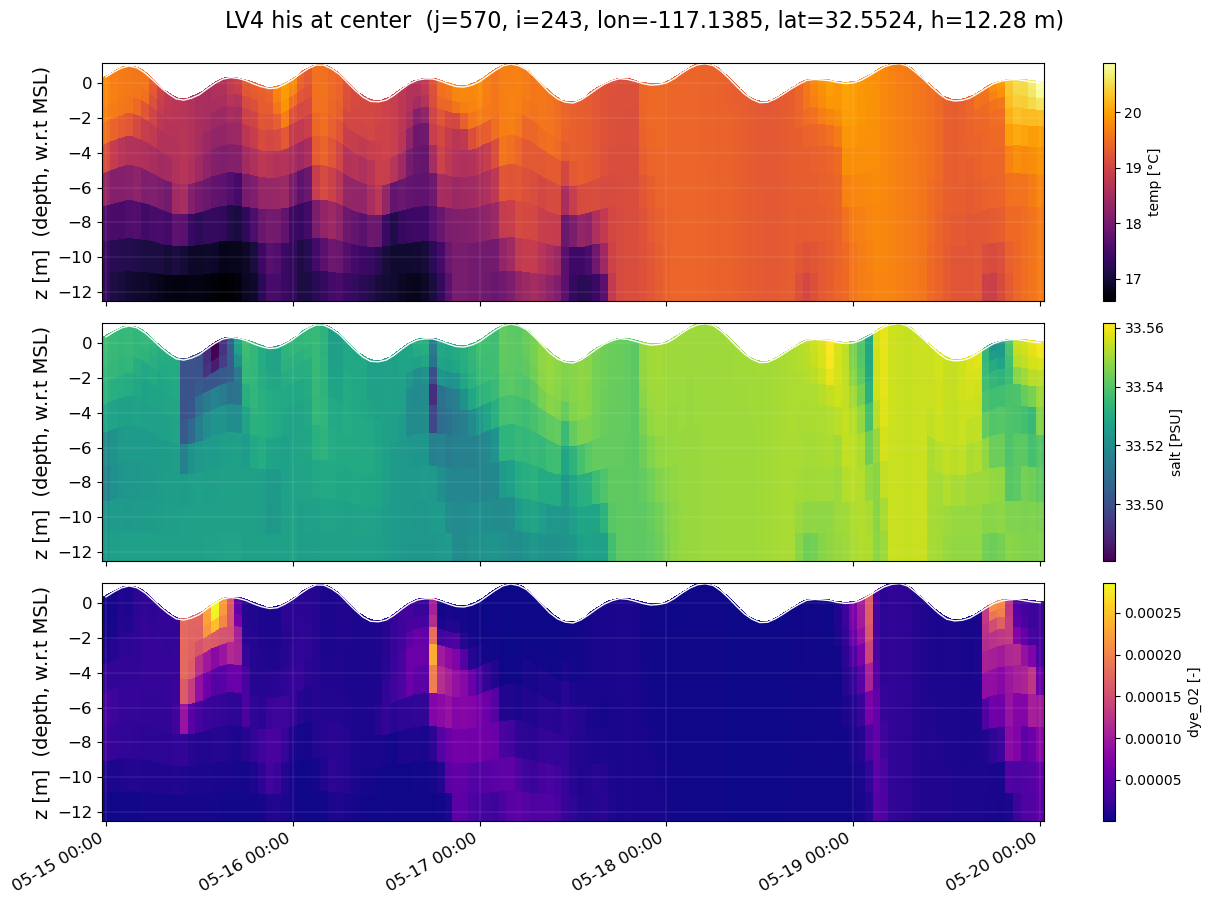

In [4]:
# Time-depth color plots of temp, salt, dye_02 from LV4 his file at the domain center.
# Depth at each time is computed from h + zeta(t) using Vtransform=2 ROMS stretching.

his_fn = '/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202605150000.nc'
grd_fn = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc'

dh = nc.Dataset(his_fn)
dg = nc.Dataset(grd_fn)

ny, nx = dh.dimensions['eta_rho'].size, dh.dimensions['xi_rho'].size
jr, ir = ny//2, nx//2
lat_pt = float(dg.variables['lat_rho'][jr, ir])
lon_pt = float(dg.variables['lon_rho'][jr, ir])
h_pt   = float(dh.variables['h'][jr, ir])
print(f'center (j={jr}, i={ir})  lon = {lon_pt:.4f}, lat = {lat_pt:.4f}  h = {h_pt:.2f} m')

# pull center column
zeta = np.array(dh.variables['zeta'][:, jr, ir])           # (T,)
T    = np.array(dh.variables['temp'][:, :, jr, ir])         # (T, k)
S    = np.array(dh.variables['salt'][:, :, jr, ir])         # (T, k)
D2   = np.array(dh.variables['dye_02'][:, :, jr, ir])       # (T, k)

# stretching info
Vtr  = int(np.array(dh.variables['Vtransform'][...]))
hc   = float(np.array(dh.variables['hc'][...]))
Cs_r = np.array(dh.variables['Cs_r'][:])                    # (k,)
s_rho = np.array(dh.variables['s_rho'][:])                  # (k,)

# z_rho at this column for each time (Vtransform=2 standard form)
# z(t,k) = zeta(t) + (zeta(t)+h) * (hc*s_rho + h*Cs_r) / (hc + h)
if Vtr == 2:
    Sk = (hc*s_rho + h_pt*Cs_r) / (hc + h_pt)               # (k,)
    z_rho = zeta[:, None] + (zeta[:, None] + h_pt) * Sk[None, :]   # (T, k)
else:
    z_rho = h_pt*((hc*s_rho + h_pt*Cs_r)/(hc + h_pt)) + zeta[:, None]*(1 + ((hc*s_rho + h_pt*Cs_r)/(hc + h_pt))/h_pt)

# decode times -- ROMS his uses 'seconds since 1999-01-01'
ot_units = dh.variables['ocean_time'].units
t = nc.num2date(dh.variables['ocean_time'][:], ot_units, only_use_python_datetimes=True, only_use_cftime_datetimes=False)
t_dt = np.array([DT.datetime(x.year, x.month, x.day, x.hour, x.minute, x.second) for x in t])
print(f'time range: {t_dt[0]}  ..  {t_dt[-1]}  ({len(t_dt)} steps)')
print(f'zeta range: [{zeta.min():.3f}, {zeta.max():.3f}] m')

# build a 2D time array matching z_rho shape so pcolormesh can use it directly
T_dt2 = np.broadcast_to(t_dt[:, None], z_rho.shape)

LBL_FS, TICK_FS, TITLE_FS = 14, 12, 16

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
specs = [
    ('temp',   T,  'temp [°C]',   'thermal' if False else 'inferno'),
    ('salt',   S,  'salt [PSU]',  'viridis'),
    ('dye_02', D2, 'dye_02 [-]',  'plasma'),
]
for ax, (name, arr, lbl, cmap) in zip(axes, specs):
    pc = ax.pcolormesh(T_dt2, z_rho, arr, cmap=cmap, shading='auto')
    cb = fig.colorbar(pc, ax=ax, label=lbl)
    cb.ax.tick_params(labelsize=TICK_FS-2)
    # also draw the free surface
    ax.plot(t_dt, zeta, 'w-', lw=1.0, label='zeta')
    ax.set_ylabel('z [m]  (depth, w.r.t MSL)', fontsize=LBL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3, color='w', lw=0.3)
axes[-1].xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))
fig.autofmt_xdate()
fig.suptitle(f'LV4 his at center  (j={jr}, i={ir}, lon={lon_pt:.4f}, lat={lat_pt:.4f}, h={h_pt:.2f} m)',
             y=1.00, fontsize=TITLE_FS)
fig.tight_layout()
plt.show()


samples: model=12625, obs=12625
time span: 2024-12-05 00:00:00  ..  2026-05-15 00:00:00
u_avg:  RMSE=0.0432 m/s   corr=0.215
v_avg:  RMSE=0.1028 m/s   corr=0.278


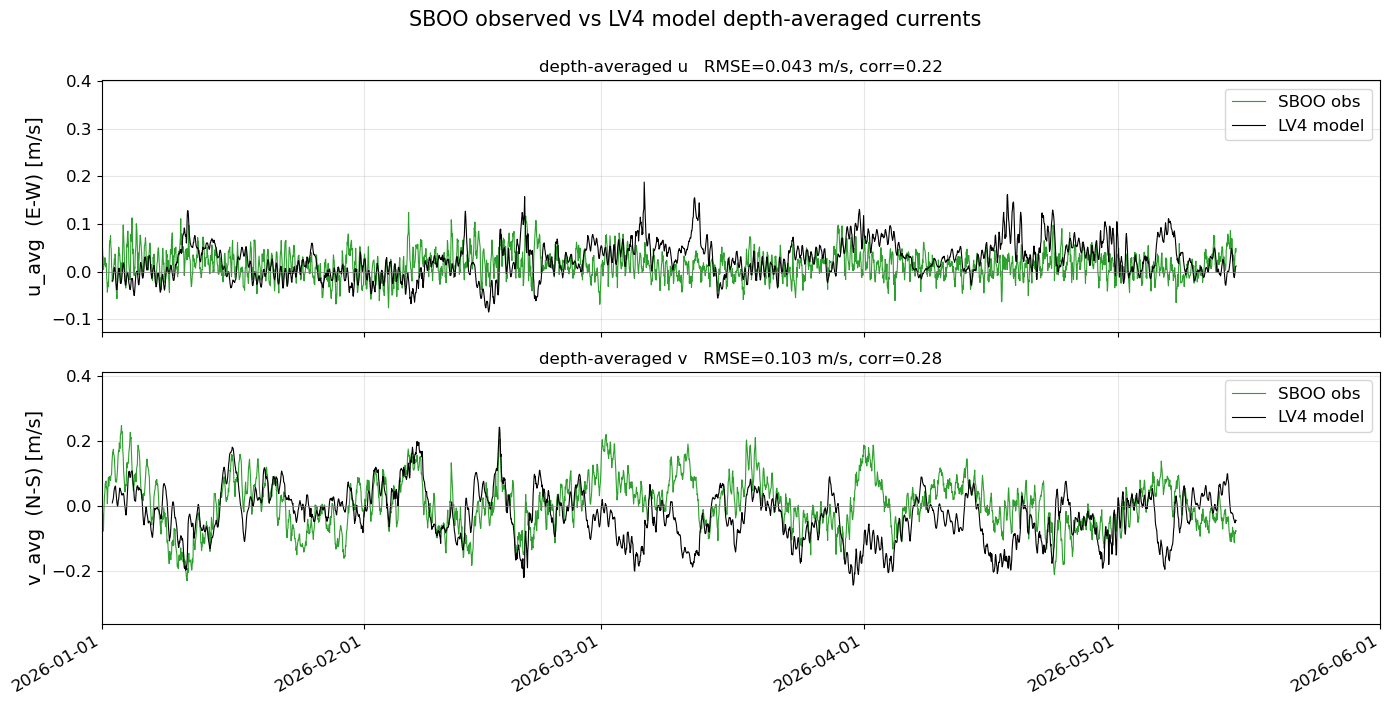

In [3]:
# Compare SBOO observed currents vs LV4 model currents (depth-averaged).
# Two .mat files in /home/mspydell/research/SBOO_currents/:
#   *_LV4_Model.mat   -- model output sampled at the SBOO location
#   *_SBOO_Obser.mat  -- ADCP observations at SBOO
# 12625 hourly points span 2024-12-05 00:00 -> 2026-05-15 00:00 (per the filenames).
import scipy.io as sio

mdir   = '/home/mspydell/research/SBOO_currents'
f_mod  = f'{mdir}/TimeSeries_05-Dec-2024_15-May-2026_LV4_Model.mat'
f_obs  = f'{mdir}/TimeSeries_05-Dec-2024_15-May-2026_SBOO_Obser.mat'

mod = sio.loadmat(f_mod, squeeze_me=True, struct_as_record=False)
obs = sio.loadmat(f_obs, squeeze_me=True, struct_as_record=False)

u_mod, v_mod = np.asarray(mod['u_avg'], float), np.asarray(mod['v_avg'], float)
u_obs, v_obs = np.asarray(obs['u_avg'], float), np.asarray(obs['v_avg'], float)
n = len(u_mod)
print(f'samples: model={n}, obs={len(u_obs)}')

# hourly time vector starting 2024-12-05 00:00
t0   = DT.datetime(2024, 12, 5, 0, 0, 0)
t_ts = np.array([t0 + DT.timedelta(hours=k) for k in range(n)])
print(f'time span: {t_ts[0]}  ..  {t_ts[-1]}')

# simple skill metrics on the overlap where both are finite
def stats(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 2:
        return float('nan'), float('nan')
    rmse = float(np.sqrt(np.mean((a[m]-b[m])**2)))
    corr = float(np.corrcoef(a[m], b[m])[0,1])
    return rmse, corr

ru, cu = stats(u_mod, u_obs)
rv, cv = stats(v_mod, v_obs)
print(f'u_avg:  RMSE={ru:.4f} m/s   corr={cu:.3f}')
print(f'v_avg:  RMSE={rv:.4f} m/s   corr={cv:.3f}')

LBL_FS, TICK_FS, TITLE_FS = 14, 12, 15
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(t_ts, u_obs, '-', lw=0.8, color='tab:green',  label='SBOO obs')
ax.plot(t_ts, u_mod, '-', lw=0.8, color='black',      label='LV4 model')
ax.set_ylabel('u_avg  (E-W) [m/s]', fontsize=LBL_FS)
ax.set_title(f'depth-averaged u   RMSE={ru:.3f} m/s, corr={cu:.2f}', fontsize=TICK_FS)

ax = axes[1]
ax.plot(t_ts, v_obs, '-', lw=0.8, color='tab:green',  label='SBOO obs')
ax.plot(t_ts, v_mod, '-', lw=0.8, color='black',      label='LV4 model')
ax.set_ylabel('v_avg  (N-S) [m/s]', fontsize=LBL_FS)
ax.set_title(f'depth-averaged v   RMSE={rv:.3f} m/s, corr={cv:.2f}', fontsize=TICK_FS)

xlim_lo = DT.datetime(2026, 1, 1)
xlim_hi = DT.datetime(2026, 6, 1)
for ax in axes:
    ax.axhline(0, color='gray', lw=0.5)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=TICK_FS)
    ax.set_xlim(xlim_lo, xlim_hi)
axes[-1].xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
fig.suptitle('SBOO observed vs LV4 model depth-averaged currents', y=1.00, fontsize=TITLE_FS)
fig.tight_layout()
plt.show()


loaded cached currents from /home/mspydell/research/SBOO_currents/LV234_currents_from_his.nc


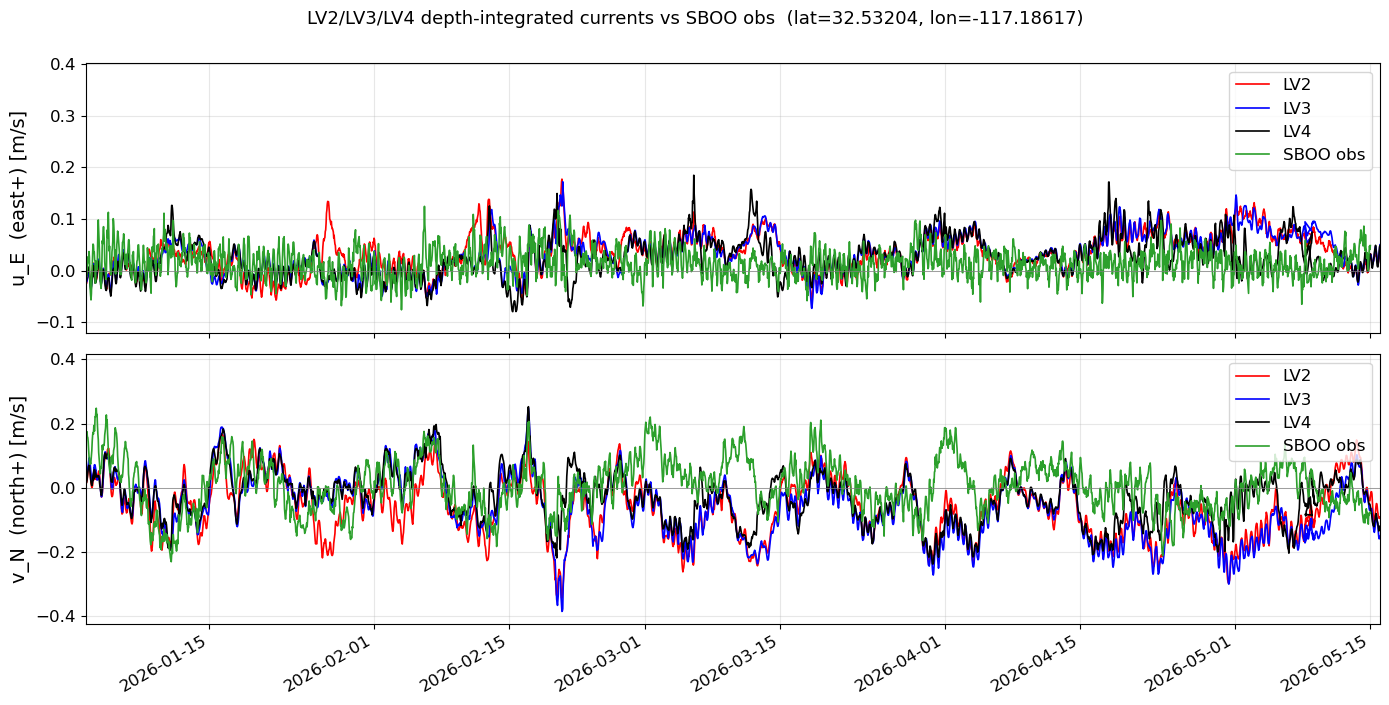

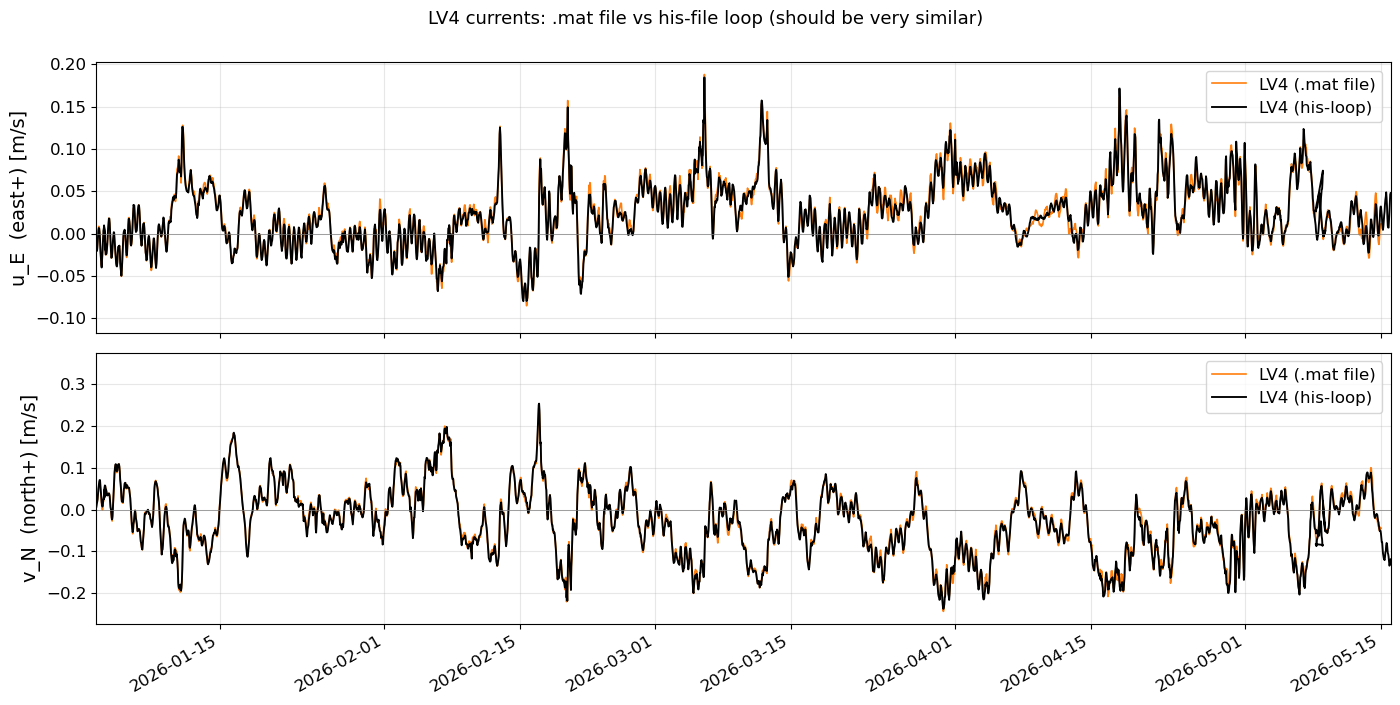

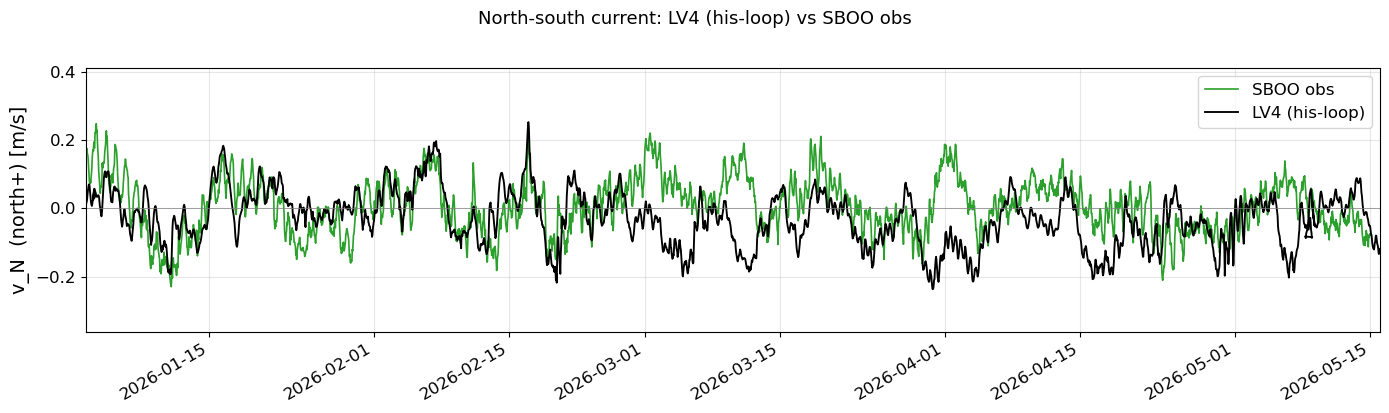

In [4]:
# LV2/LV3/LV4 depth-integrated currents at SBOO -- with .nc caching, obs overlay,
# and an LV4 (.mat) vs LV4 (his-loop) comparison figure.
# First 1 day of each his file, 2026-01-01 to 2026-05-15.  ubar/vbar are IDW-
# interpolated from the 4 rho points surrounding the target, rotated to E/N using
# each grid's own `angle`.  Looping all his files is slow, so results are cached
# to CACHE_NC; delete that file to force a recompute.
import os, glob, re
import scipy.io as sio

target_lat, target_lon = 32.532040, -117.186170
DATE_LO, DATE_HI = '202601010000', '202605151200'
DAY_CUTOFF = 1.0
CACHE_NC = '/home/mspydell/research/SBOO_currents/LV234_currents_from_his.nc'

LEVELS = {
    'LV2': dict(his='/dataSIO/PFM_Simulations/Archive/LV2_His',
                grd='/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV2_rx020.nc',
                color='red'),
    'LV3': dict(his='/dataSIO/PFM_Simulations/Archive/LV3_His',
                grd='/dataSIO/PFM_Simulations/Grid/GRID_SDTJRE_LV3_rx020.nc',
                color='blue'),
    'LV4': dict(his='/dataSIO/PFM_Simulations/Archive/LV4_His',
                grd='/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc',
                color='black'),
}

def extract_level(level, his_dir, grd_fn, tlat, tlon, day_cutoff=1.0):
    g   = nc.Dataset(grd_fn)
    lat = np.array(g.variables['lat_rho'][:])
    lon = np.array(g.variables['lon_rho'][:])
    ang = np.array(g.variables['angle'][:])
    ny, nx = lat.shape
    dist   = np.sqrt((lat - tlat)**2 + (lon - tlon)**2)
    j0, i0 = np.unravel_index(np.argmin(dist), dist.shape)
    j0 = int(np.clip(j0, 1, ny-2)); i0 = int(np.clip(i0, 1, nx-2))
    best = None
    for dj in (-1, 1):
        for di in (-1, 1):
            jj, ii = [j0, j0+dj], [i0, i0+di]
            clat = np.mean([lat[a,b] for a in jj for b in ii])
            clon = np.mean([lon[a,b] for a in jj for b in ii])
            dd = (clat-tlat)**2 + (clon-tlon)**2
            if best is None or dd < best[0]:
                best = (dd, dj, di)
    _, dj, di = best
    jlo, jhi = sorted([j0, j0+dj])
    ilo, ihi = sorted([i0, i0+di])
    w = np.zeros((2,2))
    for a, jj in enumerate((jlo, jhi)):
        for b, ii in enumerate((ilo, ihi)):
            d2 = (lat[jj,ii]-tlat)**2 + (lon[jj,ii]-tlon)**2
            w[a,b] = 1.0/max(d2, 1e-12)
    w /= w.sum()
    ang_blk = np.array([[ang[jj,ii] for ii in (ilo,ihi)] for jj in (jlo,jhi)])
    ang_pt  = float(np.sum(w*ang_blk))
    cosA, sinA = np.cos(ang_pt), np.sin(ang_pt)

    date_re = re.compile(rf'{level}_ocean_his_(\d{{12}})\.nc$')
    paths   = sorted(glob.glob(os.path.join(his_dir, f'{level}_ocean_his_2026*.nc')))
    files   = [p for p in paths
               if (m := date_re.search(p)) and DATE_LO <= m.group(1) <= DATE_HI]

    times, uE, vN, seams = [], [], [], []
    for fp in files:
        try:
            d = nc.Dataset(fp)
        except Exception as e:
            print('  skip', os.path.basename(fp), '->', e); continue
        t = nc.num2date(d.variables['ocean_time'][:], d.variables['ocean_time'].units,
                        only_use_python_datetimes=True, only_use_cftime_datetimes=False)
        t_dt = np.array([DT.datetime(x.year,x.month,x.day,x.hour,x.minute,x.second) for x in t])
        keep = t_dt <= t_dt[0] + DT.timedelta(days=day_cutoff)
        if not keep.any():
            d.close(); continue
        sel = np.where(keep)[0]
        ub = np.array(d.variables['ubar'][sel, jlo:jhi+1, ilo-1:ihi+1])   # (n,2,3)
        ub_rho = 0.5*(ub[:,:,:-1] + ub[:,:,1:])                          # (n,2,2)
        vb = np.array(d.variables['vbar'][sel, jlo-1:jhi+1, ilo:ihi+1])   # (n,3,2)
        vb_rho = 0.5*(vb[:,:-1,:] + vb[:,1:,:])                          # (n,2,2)
        ub_i = np.sum(ub_rho * w[None,:,:], axis=(1,2))
        vb_i = np.sum(vb_rho * w[None,:,:], axis=(1,2))
        uE.append(ub_i*cosA - vb_i*sinA)
        vN.append(ub_i*sinA + vb_i*cosA)
        times.append(t_dt[keep]); seams.append(t_dt[keep][0])
        d.close()
    info = dict(j0=j0, i0=i0, jlo=jlo, jhi=jhi, ilo=ilo, ihi=ihi,
                ang_deg=np.degrees(ang_pt), nfiles=len(files))
    return np.concatenate(times), np.concatenate(uE), np.concatenate(vN), seams, info

TUNITS = 'seconds since 1970-01-01 00:00:00'

def save_cache(path, results, tlat, tlon):
    with nc.Dataset(path, 'w') as d:
        d.description = 'LV2/LV3/LV4 depth-integrated currents at SBOO from his-file loop'
        d.target_lat  = tlat
        d.target_lon  = tlon
        d.date_lo     = DATE_LO
        d.date_hi     = DATE_HI
        d.day_cutoff  = DAY_CUTOFF
        for lv in ('LV2','LV3','LV4'):
            r  = results[lv]
            ln = lv.lower()
            dn = f'time_{ln}'
            d.createDimension(dn, len(r['t']))
            tv = d.createVariable(f'ocean_time_{ln}', 'f8', (dn,)); tv.units = TUNITS
            tv[:] = nc.date2num(list(r['t']), TUNITS)
            uv = d.createVariable(f'u_{ln}', 'f8', (dn,))
            vv = d.createVariable(f'v_{ln}', 'f8', (dn,))
            uv[:] = r['uE']; vv[:] = r['vN']
            uv.long_name = f'{lv} eastward depth-integrated current at SBOO'
            vv.long_name = f'{lv} northward depth-integrated current at SBOO'
            uv.units = vv.units = 'm/s'
    print('saved cache ->', path)

def load_cache(path):
    out = {}
    with nc.Dataset(path) as d:
        for lv in ('LV2','LV3','LV4'):
            ln = lv.lower()
            tv = d.variables[f'ocean_time_{ln}']
            t  = nc.num2date(tv[:], tv.units, only_use_python_datetimes=True,
                             only_use_cftime_datetimes=False)
            t  = np.array([DT.datetime(x.year,x.month,x.day,x.hour,x.minute,x.second) for x in t])
            out[lv] = dict(t=t,
                           uE=np.array(d.variables[f'u_{ln}'][:]),
                           vN=np.array(d.variables[f'v_{ln}'][:]),
                           seams=[], color=LEVELS[lv]['color'])
        meta = dict(target_lat=float(d.target_lat), target_lon=float(d.target_lon),
                    date_lo=str(d.date_lo), date_hi=str(d.date_hi))
    return out, meta

# ---- get LV2/3/4 currents: from cache if valid, else loop his files + save ----
use_cache = False
if os.path.exists(CACHE_NC):
    try:
        results, meta = load_cache(CACHE_NC)
        if (abs(meta['target_lat']-target_lat) < 1e-6 and abs(meta['target_lon']-target_lon) < 1e-6
                and meta['date_lo'] == DATE_LO and meta['date_hi'] == DATE_HI):
            use_cache = True
            print(f'loaded cached currents from {CACHE_NC}')
        else:
            print('cache target/date range differs from request -- recomputing')
    except Exception as e:
        print('cache load failed:', e, '-- recomputing')

if not use_cache:
    results = {}
    for lv, cfg in LEVELS.items():
        t_all, uE, vN, seams, info = extract_level(lv, cfg['his'], cfg['grd'],
                                                   target_lat, target_lon, DAY_CUTOFF)
        results[lv] = dict(t=t_all, uE=uE, vN=vN, seams=seams,
                           info=info, color=cfg['color'])
        print(f'{lv}: {info["nfiles"]} files, {len(t_all)} samples; rotation {info["ang_deg"]:.2f} deg')
    save_cache(CACHE_NC, results, target_lat, target_lon)

# ---- load SBOO observations + LV4 .mat model (depth-averaged u_avg/v_avg) ----
mdir   = '/home/mspydell/research/SBOO_currents'
obs_mat = sio.loadmat(f'{mdir}/TimeSeries_05-Dec-2024_15-May-2026_SBOO_Obser.mat', squeeze_me=True)
mod_mat = sio.loadmat(f'{mdir}/TimeSeries_05-Dec-2024_15-May-2026_LV4_Model.mat', squeeze_me=True)
u_obs = np.asarray(obs_mat['u_avg'], float); v_obs = np.asarray(obs_mat['v_avg'], float)
u_mat = np.asarray(mod_mat['u_avg'], float); v_mat = np.asarray(mod_mat['v_avg'], float)
t0_mat = DT.datetime(2024, 12, 5, 0, 0, 0)
t_mat  = np.array([t0_mat + DT.timedelta(hours=k) for k in range(len(u_obs))])

# common time window = span of the LV4 his-loop currents
x_lo = min(results[lv]['t'][0]  for lv in ('LV2','LV3','LV4'))
x_hi = max(results[lv]['t'][-1] for lv in ('LV2','LV3','LV4'))

LBL_FS, TICK_FS, TITLE_FS = 14, 12, 15

# ===== Figure 1: LV2/LV3/LV4 his-loop currents + SBOO observations =====
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for lv in ('LV2','LV3','LV4'):
    r = results[lv]
    axes[0].plot(r['t'], r['uE'], '-', lw=1.2, color=r['color'], label=lv)
    axes[1].plot(r['t'], r['vN'], '-', lw=1.2, color=r['color'], label=lv)
axes[0].plot(t_mat, u_obs, '-', lw=1.2, color='tab:green', label='SBOO obs')
axes[1].plot(t_mat, v_obs, '-', lw=1.2, color='tab:green', label='SBOO obs')
axes[0].set_ylabel('u_E  (east+) [m/s]', fontsize=LBL_FS)
axes[1].set_ylabel('v_N  (north+) [m/s]', fontsize=LBL_FS)
for ax in axes:
    ax.axhline(0, color='gray', lw=0.5)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=TICK_FS)
    ax.set_xlim(x_lo, x_hi)
axes[-1].xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
fig.suptitle(f'LV2/LV3/LV4 depth-integrated currents vs SBOO obs  '
             f'(lat={target_lat:.5f}, lon={target_lon:.5f})', y=1.00, fontsize=TITLE_FS-2)
fig.tight_layout()
plt.show()

# ===== Figure 2: LV4 from .mat file vs LV4 from the his-file loop =====
fig2, ax2 = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
r4 = results['LV4']
ax2[0].plot(t_mat, u_mat, '-', lw=1.2, color='tab:orange', label='LV4 (.mat file)')
ax2[0].plot(r4['t'], r4['uE'], '-', lw=1.35, color='black', label='LV4 (his-loop)')
ax2[1].plot(t_mat, v_mat, '-', lw=1.2, color='tab:orange', label='LV4 (.mat file)')
ax2[1].plot(r4['t'], r4['vN'], '-', lw=1.35, color='black', label='LV4 (his-loop)')
ax2[0].set_ylabel('u_E  (east+) [m/s]', fontsize=LBL_FS)
ax2[1].set_ylabel('v_N  (north+) [m/s]', fontsize=LBL_FS)
for ax in ax2:
    ax.axhline(0, color='gray', lw=0.5)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=TICK_FS)
    ax.set_xlim(x_lo, x_hi)
ax2[-1].xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
fig2.autofmt_xdate()
fig2.suptitle('LV4 currents: .mat file vs his-file loop (should be very similar)',
              y=1.00, fontsize=TITLE_FS-2)
fig2.tight_layout()
plt.show()

# ===== Figure 3: LV4 (his-loop) vs SBOO obs -- north-south (v_N) only =====
fig3, ax3 = plt.subplots(1, 1, figsize=(14, 4))
ax3.plot(t_mat, v_obs, '-', lw=1.2, color='tab:green', label='SBOO obs')
ax3.plot(r4['t'], r4['vN'], '-', lw=1.35, color='black', label='LV4 (his-loop)')
ax3.axhline(0, color='gray', lw=0.5)
ax3.set_ylabel('v_N  (north+) [m/s]', fontsize=LBL_FS)
ax3.tick_params(axis='both', labelsize=TICK_FS)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='best', fontsize=TICK_FS)
ax3.set_xlim(x_lo, x_hi)
ax3.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
fig3.autofmt_xdate()
fig3.suptitle('North-south current: LV4 (his-loop) vs SBOO obs', y=1.02, fontsize=TITLE_FS-2)
fig3.tight_layout()
plt.show()


In [ ]:
# ===== v_N (north-south) at SBOO: obs + LV1 + LV4 =====
# Same target as the LV2/3/4 cell above (SBOO), same time window (x_lo..x_hi).
# LV1's grid resolution (~2 km) means the naive nearest-rho to (target_lat,
# target_lon) can land on a coastal LAND cell.  We compute the nearest
# *wet* rho instead so LV1 is sampled just offshore of SBOO; the extract_level
# helper then rotates ubar/vbar using LV1's own grid angle (different from LV4).

LV1_HIS_DIR = '/dataSIO/PFM_Simulations/Archive/LV1_His'
LV1_GRID    = '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV1_rx020_hmask.nc'

_g1   = nc.Dataset(LV1_GRID)
_lat1 = np.array(_g1.variables['lat_rho'][:])
_lon1 = np.array(_g1.variables['lon_rho'][:])
_msk1 = np.array(_g1.variables['mask_rho'][:], dtype=bool)   # True = water
_d1   = (_lat1 - target_lat)**2 + (_lon1 - target_lon)**2
_d1_wet = np.where(_msk1, _d1, np.inf)
_jr1, _ir1 = np.unravel_index(np.argmin(_d1_wet), _d1_wet.shape)
TLAT_LV1, TLON_LV1 = float(_lat1[_jr1, _ir1]), float(_lon1[_jr1, _ir1])
# rough distance to actual SBOO location (deg -> km at 32.5N)
_km = float(np.hypot((TLAT_LV1 - target_lat)*111.0,
                     (TLON_LV1 - target_lon)*93.6))
print(f'LV1 nearest WET rho to SBOO: (j={_jr1}, i={_ir1})  '
      f'lon={TLON_LV1:.4f}, lat={TLAT_LV1:.4f}  '
      f'({_km:.2f} km offshore of SBOO)')

# Extract LV1 currents at the offshore-nearest wet point.
# extract_level: reads first `DAY_CUTOFF` day(s) of each LV1 his.nc in
# [DATE_LO, DATE_HI], IDW-interps ubar/vbar to the target, rotates by
# the LV1 grid's own angle to true east/north.
t_all_lv1, uE_lv1, vN_lv1, seams_lv1, info_lv1 = extract_level(
    'LV1', LV1_HIS_DIR, LV1_GRID, TLAT_LV1, TLON_LV1, DAY_CUTOFF)
print(f'LV1: {info_lv1["nfiles"]} files, {len(t_all_lv1)} samples; '
      f'rotation {info_lv1["ang_deg"]:.2f} deg')
print(f'LV4: {len(results["LV4"]["t"])} samples; '
      f'rotation {results["LV4"]["info"]["ang_deg"]:.2f} deg')


LV1 nearest WET rho to SBOO: (j=145, i=238)  lon=-117.1900, lat=32.5297  (0.44 km offshore of SBOO)
LV1: 135 files, 3375 samples; rotation 23.36 deg


KeyError: 'info'

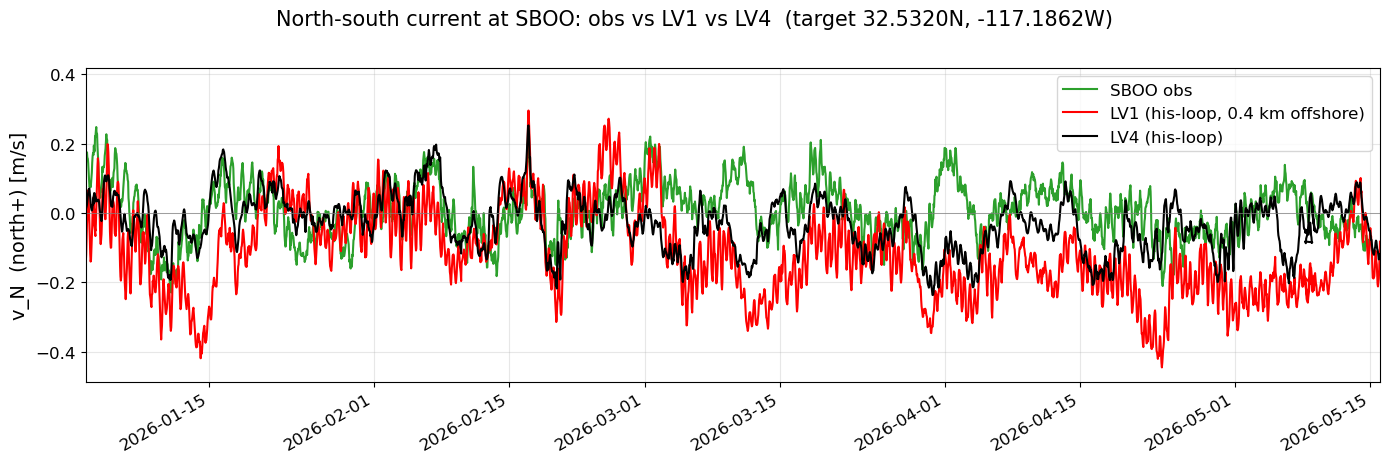

In [ ]:

# ---- plot v_N only: obs, LV1, LV4 ----
LBL_FS, TICK_FS, TITLE_FS = 14, 12, 15
fig4, ax4 = plt.subplots(1, 1, figsize=(14, 4.5))
ax4.plot(t_mat,                     v_obs,               '-', lw=1.5,
         color='tab:green', label='SBOO obs')
ax4.plot(t_all_lv1,                 vN_lv1,              '-', lw=1.5,
         color='red',       label=f'LV1 (his-loop, {_km:.1f} km offshore)')
ax4.plot(results['LV4']['t'],       results['LV4']['vN'], '-', lw=1.5,
         color='black',     label='LV4 (his-loop)')
ax4.axhline(0, color='gray', lw=0.5)
ax4.set_ylabel('v_N  (north+) [m/s]', fontsize=LBL_FS)
ax4.tick_params(axis='both', labelsize=TICK_FS)
ax4.grid(True, alpha=0.3)
ax4.legend(loc='best', fontsize=TICK_FS)
ax4.set_xlim(x_lo, x_hi)
ax4.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
fig4.autofmt_xdate()
fig4.suptitle(f'North-south current at SBOO: obs vs LV1 vs LV4  '
              f'(target {target_lat:.4f}N, {target_lon:.4f}W)',
              y=1.02, fontsize=TITLE_FS)
fig4.tight_layout()
plt.show()

